In [3]:
from pathlib import Path
import kagglehub

WK = Path(".").resolve()
AIP_ROOT = WK if (WK / "src" / "config.py").is_file() else WK / "AIP"
DATA_DIR = AIP_ROOT / "data"
BRISC_PATH = DATA_DIR / "brisc2025"
if not (BRISC_PATH.is_dir() and any(BRISC_PATH.iterdir())):
    kagglehub.dataset_download("briscdataset/brisc2025", output_dir=str(DATA_DIR))

Разбиение данных по анатомическим плоскостям (ax / sa / co)

In [ ]:
import shutil
from pathlib import Path

WK = Path(".").resolve()
AIP_ROOT = WK if (WK / "src" / "config.py").is_file() else WK / "AIP"
DATA = AIP_ROOT / "data"
BRISC = DATA / "brisc2025"

TUMOR_MAP = {"gl": "glioma", "me": "meningioma", "pi": "pituitary", "no": "no_tumor"}
PLANES = ("ax", "sa", "co")

already_split = all((DATA / "classification_task" / p).is_dir() and (DATA / "segmentation_task" / p).is_dir() for p in PLANES)

if already_split:
    print("Данные уже разбиты по плоскостям")
else:
    def parse_filename(name: str):
        parts = name.split("_")
        return parts[1], parts[3], parts[4]

    cls_src = BRISC / "classification_task"
    for img in cls_src.rglob("*.jpg"):
        split, tumor, plane = parse_filename(img.stem)
        dest = DATA / "classification_task" / plane / split / TUMOR_MAP[tumor]
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy2(img, dest / img.name)

    seg_src = BRISC / "segmentation_task"
    for img in seg_src.rglob("*.jpg"):
        split, tumor, plane = parse_filename(img.stem)
        dest = DATA / "segmentation_task" / plane / split / "images"
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy2(img, dest / img.name)

    for mask in seg_src.rglob("*.png"):
        split, tumor, plane = parse_filename(mask.stem)
        dest = DATA / "segmentation_task" / plane / split / "masks"
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy2(mask, dest / mask.name)


Данные уже разбиты по плоскостям, пропускаем


In [5]:
import pandas as pd

rows = []
for img in (DATA / "classification_task").rglob("*.jpg"):
    plane = img.parts[-4]  # ax / sa / co
    split = img.parts[-3]  # train / test
    label = img.parts[-2]  # glioma / meningioma / ...
    rows.append({"plane": plane, "split": split, "class": label})

df = pd.DataFrame(rows)
pivot = df.pivot_table(index=["plane", "class"], columns="split", aggfunc="size", fill_value=0)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_index()

print(pivot.to_string())
print(f"Всего {len(df)}")  

split             test  train  total
plane class                         
ax    glioma        85    394    479
      meningioma   137    423    560
      no_tumor      52    352    404
      pituitary    124    426    550
co    glioma        81    430    511
      meningioma    86    426    512
      no_tumor      48    310    358
      pituitary     90    510    600
sa    glioma        88    323    411
      meningioma    83    480    563
      no_tumor      40    405    445
      pituitary     86    521    607
Всего 6000


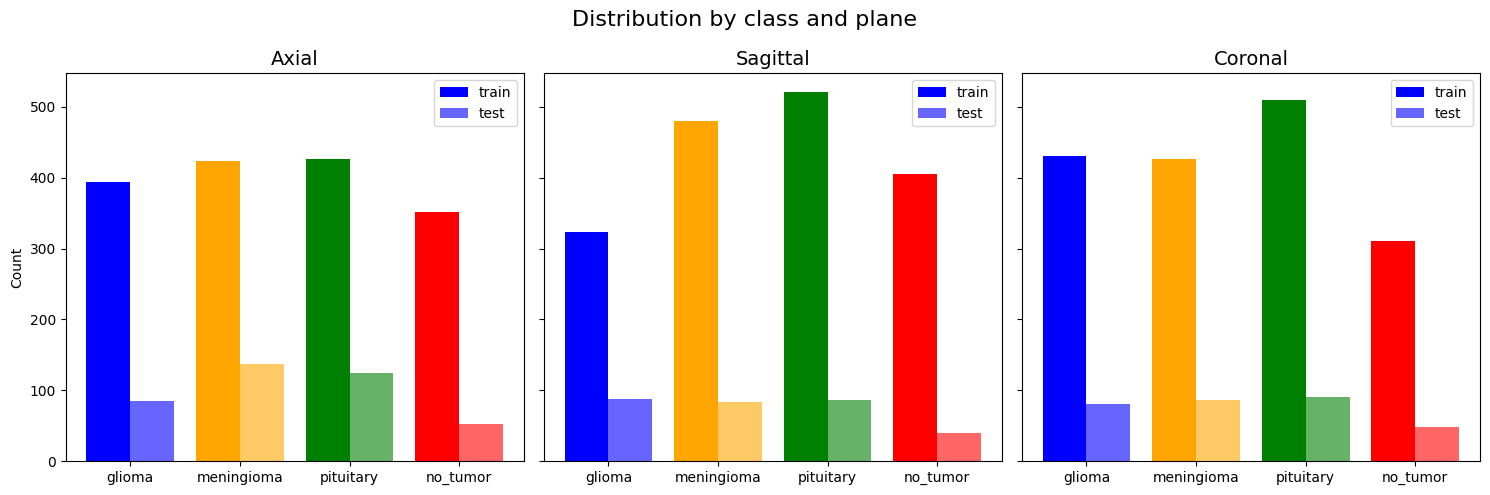

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plane_names = {"ax": "Axial", "sa": "Sagittal", "co": "Coronal"}
classes = ["glioma", "meningioma", "pituitary", "no_tumor"]
colors = ["Blue", "Orange", "Green", "Red"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax_plot, plane in zip(axes, ["ax", "sa", "co"]):
    sub = df[df["plane"] == plane]
    counts = sub.groupby(["class", "split"]).size().unstack(fill_value=0).reindex(classes)

    x = np.arange(len(classes))
    w = 0.4
    ax_plot.bar(x - w / 2, counts["train"], w, label="train", color=colors)
    ax_plot.bar(x + w / 2, counts["test"], w, label="test", alpha=0.6, color=colors)

    ax_plot.set_title(plane_names[plane], fontsize=14)
    ax_plot.set_xticks(x)
    ax_plot.set_xticklabels(classes)
    ax_plot.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Distribution by class and plane", fontsize=16)
plt.tight_layout()
plt.show()